# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Alvin Hizra Muhammad
- **Email:** alvinhizra9@gmail.com
- **ID Dicoding:** [Input Username]

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip -q install tensorflowjs

In [2]:
import glob
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import shutil
import pandas as pd
import tensorflow as tf
import tensorflowjs as tfjs

from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras import mixed_precision
from tensorflow.keras import layers

## Data Preparation

### Data Loading

In [3]:
# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [4]:
train_dir = os.path.join(path, "Train")
test_dir  = os.path.join(path, "Test")

print("Train dir exists?", os.path.exists(train_dir))
print("Test dir exists? ", os.path.exists(test_dir))

if os.path.exists(train_dir):
    class_folders = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    print("Jumlah folder kelas di Train:", len(class_folders))
    print("View nama folder kelas:", class_folders[:10])

Train dir exists? True
Test dir exists?  True
Jumlah folder kelas di Train: 43
View nama folder kelas: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']


In [5]:
def count_images(root):
    exts = ("*.png","*.jpg","*.jpeg","*.ppm")
    total = 0
    for e in exts:
        total += len(glob.glob(os.path.join(root, "**", e), recursive=True))
    return total

print("Total images in Train:", count_images(train_dir) if os.path.exists(train_dir) else None)
print("Total images in Test :", count_images(test_dir)  if os.path.exists(test_dir)  else None)

Total images in Train: 39209
Total images in Test : 12630


In [6]:
random.seed(123)

# ambil file gambar dari Train
all_imgs = []
for ext in ("png","jpg","jpeg","ppm"):
    all_imgs += glob.glob(os.path.join(train_dir, "**", f"*.{ext}"), recursive=True)

sample = random.sample(all_imgs, k=20)

sizes = set()
for p in sample:
    img = Image.open(p)
    sizes.add(img.size)  # (Width,Height)
    # tampilkan beberapa sample
    print(img.size, "->", p.replace(path, "").split("/")[2] if "/Train/" in p else "unknown")

print("Jumlah ukuran unique (dari 20 sampel):", len(sizes))

(47, 41) -> 2
(29, 31) -> 38
(53, 57) -> 35
(52, 51) -> 15
(48, 47) -> 38
(77, 74) -> 23
(35, 39) -> 17
(47, 43) -> 13
(30, 30) -> 9
(53, 51) -> 11
(128, 111) -> 18
(99, 85) -> 18
(51, 54) -> 2
(32, 32) -> 5
(40, 40) -> 10
(50, 47) -> 18
(84, 75) -> 11
(69, 60) -> 18
(39, 39) -> 38
(48, 47) -> 5
Jumlah ukuran unique (dari 20 sampel): 19


In [7]:
print(sorted(os.listdir(path))[:50])

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv', 'meta', 'test', 'train']


In [8]:
test_dir = os.path.join(path, "Test")
print("Sample Isi Test:", sorted(os.listdir(test_dir))[:20])

Sample Isi Test: ['00000.png', '00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png', '00010.png', '00011.png', '00012.png', '00013.png', '00014.png', '00015.png', '00016.png', '00017.png', '00018.png', '00019.png']


In [9]:
test_csv = os.path.join(path, "Test.csv")

df_test = pd.read_csv(test_csv)
print("Kolom Test.csv:", list(df_test.columns))
print("Jumlah baris:", len(df_test))
df_test.head(5)

Kolom Test.csv: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Jumlah baris: 12630


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [10]:
print("Min ClassId:", df_test["ClassId"].min())
print("Max ClassId:", df_test["ClassId"].max())
print("Unique ClassId count:", df_test["ClassId"].nunique())

Min ClassId: 0
Max ClassId: 42
Unique ClassId count: 43


### Data Preprocessing

#### Split Dataset

In [11]:
BASE_PATH = path
df_train = pd.read_csv(os.path.join(BASE_PATH, "Train.csv"))
print(df_train.columns.tolist())
print(df_train["Path"].head(3).tolist())
print("Unique classes:", df_train["ClassId"].nunique())

['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
['Train/20/00020_00000_00000.png', 'Train/20/00020_00000_00001.png', 'Train/20/00020_00000_00002.png']
Unique classes: 43


In [12]:
# gabungkan semua data sehingga tidak pakai split bawaan
df_all = pd.concat([df_train, df_test], ignore_index=True)

train_df, temp_df = train_test_split(
    df_all,
    test_size=0.2,          # sisa 20% untuk val+test
    random_state=123,
    stratify=df_all["ClassId"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,          # bagi dua: 10% val, 10% test
    random_state=123,
    stratify=temp_df["ClassId"]
)

print(len(train_df), len(val_df), len(test_df), df_train["ClassId"].nunique())

41471 5184 5184 43


In [13]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(df, shuffle=False):
    paths = [os.path.join(BASE_PATH, p) for p in df["Path"].tolist()]
    labels = df["ClassId"].astype("int32").tolist()

    x1 = df["Roi.X1"].astype("int32").tolist()
    y1 = df["Roi.Y1"].astype("int32").tolist()
    x2 = df["Roi.X2"].astype("int32").tolist()
    y2 = df["Roi.Y2"].astype("int32").tolist()

    ds = tf.data.Dataset.from_tensor_slices((paths, labels, x1, y1, x2, y2))
    if shuffle:
        ds = ds.shuffle(20000, seed=123, reshuffle_each_iteration=True)

    def _load(path, label, x1, y1, x2, y2):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_png(img_bytes, channels=3)

        h = tf.maximum(1, y2 - y1)
        w = tf.maximum(1, x2 - x1)
        img = tf.image.crop_to_bounding_box(img, y1, x1, h, w)

        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        return img, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds3 = make_ds(train_df, shuffle=True)
val_ds3   = make_ds(val_df, shuffle=False)
test_ds3  = make_ds(test_df, shuffle=False)   # ini test split buatan sendiri

## Modelling

In [14]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
mixed_precision.set_global_policy("mixed_float16")
print("Policy:", mixed_precision.global_policy())

Policy: <DTypePolicy "mixed_float16">


In [16]:
NUM_CLASSES = 43

data_aug = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
])

model = tf.keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    data_aug,

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32"),
])

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [17]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_128.keras", monitor="val_accuracy",
                                       save_best_only=True, mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                     restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2,
                                         patience=2, min_lr=1e-6),
]

In [18]:
history = model.fit(
    train_ds3,
    validation_data=val_ds3,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 249s 360ms/step - accuracy: 0.1212 - loss: 3.1806 - val_accuracy: 0.3206 - val_loss: 2.2858 - learning_rate: 0.0010
Epoch 2/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.3195 - loss: 2.1785 - val_accuracy: 0.5376 - val_loss: 1.4000 - learning_rate: 0.0010
Epoch 3/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.5042 - loss: 1.4632 - val_accuracy: 0.7166 - val_loss: 0.8727 - learning_rate: 0.0010
Epoch 4/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.6597 - loss: 1.0129 - val_accuracy: 0.8592 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 5/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.7679 - loss: 0.6871 - val_accuracy: 0.9379 - val_loss: 0.2520 - learning_rate: 0.0010
Epoch 6/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.8448 - loss: 0.4829 - val_accuracy: 0.9547 - val_loss: 0.2002 - learning_rate: 0.0010
Epoch 7/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.8871 -

## Evaluasi dan Visualisasi

In [19]:
best_model = tf.keras.models.load_model("best_128.keras")
print("Best Train accuracy:", best_model.evaluate(train_ds3, verbose=0)[1])
print("Best Test  accuracy:", best_model.evaluate(test_ds3,  verbose=0)[1])

Best Train accuracy: 0.9988184571266174
Best Test  accuracy: 0.9984567761421204


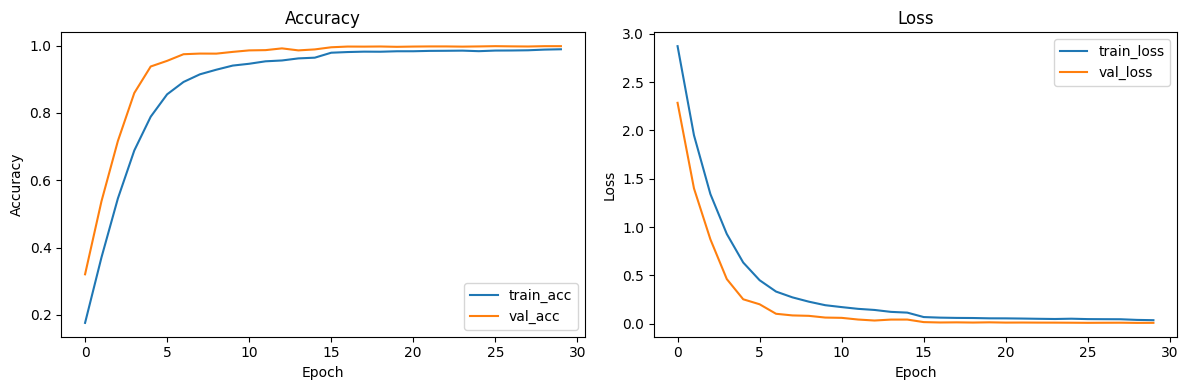

In [20]:
acc = history.history.get("accuracy", [])
val_acc = history.history.get("val_accuracy", [])
loss = history.history.get("loss", [])
val_loss = history.history.get("val_loss", [])

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(acc, label="train_acc")
plt.plot(val_acc, label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Konversi Model

In [21]:
SUB_DIR = "/content/submission"

if os.path.exists(SUB_DIR):
    shutil.rmtree(SUB_DIR)

os.makedirs(os.path.join(SUB_DIR, "saved_model"), exist_ok=True)
os.makedirs(os.path.join(SUB_DIR, "tflite"), exist_ok=True)
os.makedirs(os.path.join(SUB_DIR, "tfjs_model"), exist_ok=True)

!ls -lah /content
!ls -lah /content/submission

total 9.0M
drwxr-xr-x 1 root root 4.0K Feb 28 02:34 .
drwxr-xr-x 1 root root 4.0K Feb 28 01:53 ..
-rw-r--r-- 1 root root 9.0M Feb 28 02:29 best_128.keras
drwxr-xr-x 4 root root 4.0K Feb  6 14:31 .config
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data
drwxr-xr-x 5 root root 4.0K Feb 28 02:34 submission
total 20K
drwxr-xr-x 5 root root 4.0K Feb 28 02:34 .
drwxr-xr-x 1 root root 4.0K Feb 28 02:34 ..
drwxr-xr-x 2 root root 4.0K Feb 28 02:34 saved_model
drwxr-xr-x 2 root root 4.0K Feb 28 02:34 tfjs_model
drwxr-xr-x 2 root root 4.0K Feb 28 02:34 tflite


In [22]:
import tensorflow as tf

best_model = tf.keras.models.load_model("/content/best_128.keras")

# cek urutan layer biar terlihat mana augmentasi
for i, layer in enumerate(best_model.layers):
    print(i, layer.name, layer.__class__.__name__)

0 rescaling Rescaling
1 sequential Sequential
2 conv2d Conv2D
3 max_pooling2d MaxPooling2D
4 conv2d_1 Conv2D
5 max_pooling2d_1 MaxPooling2D
6 conv2d_2 Conv2D
7 max_pooling2d_2 MaxPooling2D
8 conv2d_3 Conv2D
9 max_pooling2d_3 MaxPooling2D
10 global_average_pooling2d GlobalAveragePooling2D
11 dropout Dropout
12 dense Dense
13 dropout_1 Dropout
14 dense_1 Dense


In [23]:
inputs = tf.keras.Input(shape=(128, 128, 3), name="image")

x = best_model.layers[0](inputs)      # rescaling
for layer in best_model.layers[2:]:   # skip augmentation
    x = layer(x)

inference_model = tf.keras.Model(inputs, x, name="gtsrb_inference")
inference_model.summary()

Model: "gtsrb_inference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465,259 (1.77 MB)

 Trainable params: 465,259 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
saved_path = os.path.join(SUB_DIR, "saved_model")

if os.path.exists(saved_path):
    shutil.rmtree(saved_path)
os.makedirs(saved_path, exist_ok=True)

inference_model.export(saved_path)

Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  132921423636496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423636880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423637840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423637072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423638224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423638032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423637264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423637648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132922983234448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423638992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13292

In [25]:
!ls -lah /content/submission/saved_model
!ls -lah /content/submission/saved_model/variables

total 108K
drwxr-xr-x 4 root root 4.0K Feb 28 02:35 .
drwxr-xr-x 5 root root 4.0K Feb 28 02:34 ..
drwxr-xr-x 2 root root 4.0K Feb 28 02:35 assets
-rw-r--r-- 1 root root   78 Feb 28 02:35 fingerprint.pb
-rw-r--r-- 1 root root  87K Feb 28 02:35 saved_model.pb
drwxr-xr-x 2 root root 4.0K Feb 28 02:35 variables
total 3.6M
drwxr-xr-x 2 root root 4.0K Feb 28 02:35 .
drwxr-xr-x 4 root root 4.0K Feb 28 02:35 ..
-rw-r--r-- 1 root root 3.6M Feb 28 02:35 variables.data-00000-of-00001
-rw-r--r-- 1 root root 1.7K Feb 28 02:35 variables.index


In [26]:
tflite_path = os.path.join(SUB_DIR, "tflite", "model.tflite")
label_path  = os.path.join(SUB_DIR, "tflite", "label.txt")

converter = tf.lite.TFLiteConverter.from_keras_model(inference_model)

try:
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
    tflite_model = converter.convert()
except Exception as e:
    print("BUILTINS gagal, pakai SELECT_TF_OPS.")
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    tflite_model = converter.convert()

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

with open(label_path, "w") as f:
    for i in range(43):
        f.write(f"{i}\n")

Saved artifact at '/tmp/tmpuqkfkp6y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  132921423636496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423636880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423637840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423637072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423638224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423638032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423637264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423637648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132922983234448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423638992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132921423635728: Ten

In [27]:
saved_path = os.path.join(SUB_DIR, "saved_model")
tfjs_path  = os.path.join(SUB_DIR, "tfjs_model")

if os.path.exists(tfjs_path):
    shutil.rmtree(tfjs_path)
os.makedirs(tfjs_path, exist_ok=True)

tfjs.converters.convert_tf_saved_model(saved_path, tfjs_path)

weight StatefulPartitionedCall/gtsrb_inference_1/rescaling_1/Cast with shape () and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/gtsrb_inference_1/rescaling_1/Cast_1 with shape () and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/gtsrb_inference_1/conv2d_1/convolution/Cast with shape (3, 3, 3, 32) and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/gtsrb_inference_1/conv2d_1/Squeeze with shape (32,) and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/gtsrb_inference_1/conv2d_1_2/convolution/Cast with shape (3, 3, 32, 64) and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/gtsrb_inference_1/conv2d_1_2/Squeeze with shape (64,) and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/gtsrb_inference_1/conv2d_2_1/convolution/Cast with shape (3, 3, 64, 128) and dtype float16 was

## Inference (Optional)

SavedModel
True label: 1
Pred label: 1
Top prob : 0.999862551689148


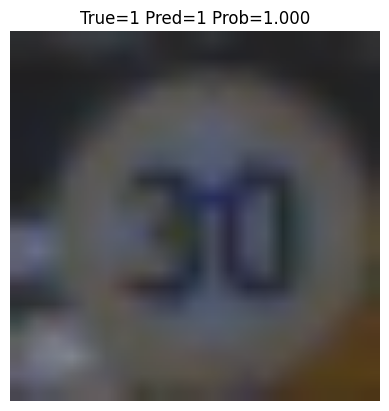

In [28]:
for images, labels in test_ds3.take(1):
    img = images[0:1]
    true_label = int(labels[0].numpy())
    break

pred = inference_model.predict(img, verbose=0)
pred_label = int(np.argmax(pred[0]))
pred_prob = float(np.max(pred[0]))

print("SavedModel")
print("True label:", true_label)
print("Pred label:", pred_label)
print("Top prob :", pred_prob)

plt.imshow(images[0].numpy().astype("uint8"))
plt.title(f"True={true_label} Pred={pred_label} Prob={pred_prob:.3f}")
plt.axis("off")
plt.show()

In [29]:
tflite_path = os.path.join(SUB_DIR, "tflite", "model.tflite")

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

x = img.numpy().astype(np.float32)  # sudah 0..255, Rescaling ada di model

interpreter.set_tensor(input_details[0]["index"], x)
interpreter.invoke()
out = interpreter.get_tensor(output_details[0]["index"])

tflite_label = int(np.argmax(out[0]))
tflite_prob = float(np.max(out[0]))

print("TFLite")
print("Pred label:", tflite_label)
print("Top prob :", tflite_prob)

TFLite
Pred label: 1
Top prob : 0.9998623132705688


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [30]:
!find /content/submission -maxdepth 2 -type f | sort

/content/submission/saved_model/fingerprint.pb
/content/submission/saved_model/saved_model.pb
/content/submission/tfjs_model/group1-shard1of1.bin
/content/submission/tfjs_model/model.json
/content/submission/tflite/label.txt
/content/submission/tflite/model.tflite


In [31]:
%cd /content
!rm -f submission.zip
!zip -r submission.zip submission
!ls -lh submission.zip

/content
  adding: submission/ (stored 0%)
  adding: submission/tfjs_model/ (stored 0%)
  adding: submission/tfjs_model/model.json (deflated 90%)
  adding: submission/tfjs_model/group1-shard1of1.bin (deflated 39%)
  adding: submission/saved_model/ (stored 0%)
  adding: submission/saved_model/fingerprint.pb (stored 0%)
  adding: submission/saved_model/saved_model.pb (deflated 85%)
  adding: submission/saved_model/variables/ (stored 0%)
  adding: submission/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: submission/saved_model/variables/variables.index (deflated 64%)
  adding: submission/saved_model/assets/ (stored 0%)
  adding: submission/tflite/ (stored 0%)
  adding: submission/tflite/model.tflite (deflated 7%)
  adding: submission/tflite/label.txt (deflated 44%)
-rw-r--r-- 1 root root 5.3M Feb 28 02:35 submission.zip


In [34]:
from google.colab import files
files.download("/content/submission.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>